# IMDB Movie Review Sentiment Analysis Using Simple RNN

This notebook builds an end-to-end binary sentiment classification pipeline using the IMDB movie review dataset and a Simple Recurrent Neural Network (RNN).

### Workflow

```text
IMDB Dataset
     ↓
Integer-Encoded Reviews
     ↓
Sequence Padding
     ↓
Embedding Layer
     ↓
Simple RNN
     ↓
Dense + Sigmoid
     ↓
Binary Sentiment Prediction
     ↓
Model Evaluation
     ↓
Save Model
```

### Notebook Objectives

1. Load and inspect the IMDB dataset
2. Understand integer-encoded reviews and labels
3. Decode a sample review for interpretation
4. Pad variable-length reviews to a fixed sequence length
5. Build a Simple RNN with an Embedding layer
6. Train using Early Stopping
7. Visualize training and validation performance
8. Evaluate on the held-out test set
9. Save the trained model in the project's `models/` directory

> **Compatibility note:** The original tutorial uses `input_length` inside `Embedding` and `ReLU` inside `SimpleRNN`. This notebook uses the current Keras input pattern with an explicit `Input(...)` layer and `tanh` for the Simple RNN. The `tanh` choice also avoids the ReLU graph/kernel warnings observed in the original Windows + TensorFlow run.

## 1. Import Required Libraries

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 2. Load the IMDB Dataset

The IMDB dataset contains 25,000 training reviews and 25,000 test reviews. Each review is represented as a sequence of integer token IDs, and the sentiment label is binary:

- `1` → Positive
- `0` → Negative

We limit the vocabulary to the top 10,000 word indices for this project.

In [2]:
max_features = 10_000

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=max_features
)

print(f"Training reviews shape: {X_train.shape}")
print(f"Training labels shape:  {y_train.shape}")
print(f"Testing reviews shape:  {X_test.shape}")
print(f"Testing labels shape:   {y_test.shape}")

Training reviews shape: (25000,)
Training labels shape:  (25000,)
Testing reviews shape:  (25000,)
Testing labels shape:   (25000,)


## 3. Inspect a Sample Review

The raw IMDB reviews are already integer encoded. Inspecting one review helps us understand what the model receives before padding.

We will also inspect its sentiment label.

In [3]:
sample_review = X_train[0]
sample_label = int(y_train[0])

print("Sample review length:", len(sample_review))
print("First 30 token IDs:", sample_review[:30])
print("Sample label:", sample_label)

Sample review length: 218
First 30 token IDs: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480]
Sample label: 1


## 4. Decode a Sample Review

The IMDB utility provides a word-to-index dictionary. We reverse that mapping so the integer token IDs can be converted back into readable text.

The IMDB format reserves special indices, so the tutorial-style decoding uses `token_id - 3`.

In [4]:
word_index = imdb.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}

decoded_review = " ".join(
    reverse_word_index.get(token_id - 3, "?")
    for token_id in sample_review
)

print(decoded_review)

? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you thi

## 5. Pad the Review Sequences

Different reviews contain different numbers of tokens. Batches passed to the neural network need a consistent sequence length.

We therefore pad or truncate every review to **500 tokens**.

- `max_length = 500`
- `padding = "pre"`

With pre-padding, zeros are added at the beginning of shorter reviews.

In [5]:
max_length = 500

X_train = pad_sequences(
    X_train,
    maxlen=max_length,
    padding="pre"
)

X_test = pad_sequences(
    X_test,
    maxlen=max_length,
    padding="pre"
)

print("Padded training shape:", X_train.shape)
print("Padded testing shape: ", X_test.shape)
print("First padded review shape:", X_train[0].shape)

Padded training shape: (25000, 500)
Padded testing shape:  (25000, 500)
First padded review shape: (500,)


### Inspect the Padded Representation

Instead of printing all 25,000 reviews, we inspect one example and only a small portion of it.

This keeps the notebook readable while still demonstrating the transformation.

In [6]:
print("First 20 padded positions:")
print(X_train[0][:20])

print("\nLast 20 padded positions:")
print(X_train[0][-20:])

First 20 padded positions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Last 20 padded positions:
[  65   16   38 1334   88   12   16  283    5   16 4472  113  103   32
   15   16 5345   19  178   32]


## 6. Build the Simple RNN Model

### Architecture

```text
Input Sequence (500 tokens)
          ↓
Embedding (128 dimensions)
          ↓
Simple RNN (128 units, tanh)
          ↓
Dense (1 unit)
          ↓
Sigmoid
          ↓
Positive / Negative
```

### Model Configuration

- Vocabulary size: `10,000`
- Maximum sequence length: `500`
- Embedding dimension: `128`
- RNN units: `128`
- Output units: `1`
- Output activation: `sigmoid`

The original tutorial used `ReLU` inside the Simple RNN. In this environment, that configuration produced abnormal first-epoch loss values and CPU graph/kernel warnings during inference. We therefore use the conventional `tanh` activation here and retrain the model from scratch.

In [7]:
embedding_dim = 128
rnn_units = 128

model = Sequential([
    Input(shape=(max_length,), dtype="int32"),

    Embedding(
        input_dim=max_features,
        output_dim=embedding_dim
    ),

    SimpleRNN(
        rnn_units,
        activation="tanh"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,025 (5.01 MB)

 Trainable params: 1,313,025 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

### Understanding the Parameter Count

The model contains three trainable components.

#### Embedding

\[
10,000 \times 128 = 1,280,000
\]

#### Simple RNN

\[
(128 + 128 + 1) \times 128 = 32,896
\]

#### Dense

\[
128 \times 1 + 1 = 129
\]

### Total

\[
1,280,000 + 32,896 + 129 = 1,313,025
\]

The expected total is therefore **1,313,025 trainable parameters**.

## 7. Compile the Model

This is a binary classification problem.

- **Adam** updates the model parameters.
- **Binary cross-entropy** measures classification loss.
- **Accuracy** tracks the proportion of correctly classified reviews.
- `clipnorm=1.0` clips the gradient norm to reduce the risk of unstable gradient updates.

In [8]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-3,
    clipnorm=1.0
)

model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## 8. Configure Early Stopping

Early Stopping monitors validation loss and stops training when the validation performance stops improving.

`restore_best_weights=True` restores the weights from the epoch with the best validation loss.

In [9]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

## 9. Train the Model

The model will train for up to 10 epochs.

A 20% validation split is taken from the training data during fitting.

> Training is performed on the current machine. On native Windows with newer TensorFlow versions, TensorFlow uses the CPU rather than the native CUDA GPU path.

In [10]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 124ms/step - accuracy: 0.5867 - loss: 0.6597 - val_accuracy: 0.7148 - val_loss: 0.5664
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 127ms/step - accuracy: 0.7581 - loss: 0.5076 - val_accuracy: 0.7626 - val_loss: 0.5242
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 123ms/step - accuracy: 0.8181 - loss: 0.4185 - val_accuracy: 0.7856 - val_loss: 0.5025
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 122ms/step - accuracy: 0.8508 - loss: 0.3578 - val_accuracy: 0.7678 - val_loss: 0.4944
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 74s 118ms/step - accuracy: 0.8684 - loss: 0.3223 - val_accuracy: 0.7724 - val_loss: 0.5979
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 125ms/step - accuracy: 0.8870 - loss: 0.2812 - val_accuracy: 0.7748 - val_loss: 0.6200
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 75s 120ms/step - accuracy: 0.9002 - loss: 0.2554 - val_accuracy: 0.7694 - val_loss: 0.6047
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 74s 118ms/step - accuracy: 0.8988 - loss: 0

## 10. Training Summary

We report the number of epochs completed and the best validation metrics rather than relying only on the final epoch.

In [11]:
history_data = history.history

best_epoch = int(np.argmin(history_data["val_loss"]) + 1)
best_val_loss = float(np.min(history_data["val_loss"]))
best_val_accuracy = float(np.max(history_data["val_accuracy"]))

print("Epochs completed:", len(history_data["loss"]))
print("Best epoch:", best_epoch)
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Best validation accuracy: {best_val_accuracy:.4f}")

Epochs completed: 9
Best epoch: 4
Best validation loss: 0.4944
Best validation accuracy: 0.7856


## 11. Visualize Training Performance

Training and validation curves help us inspect how the model learns over time.

A widening gap between training and validation performance can indicate overfitting.

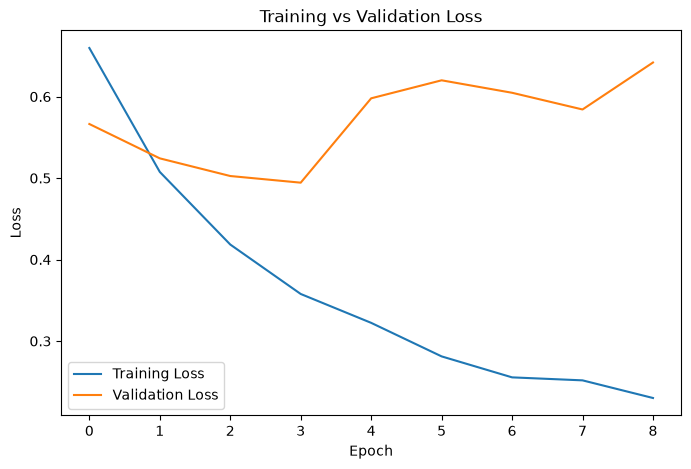

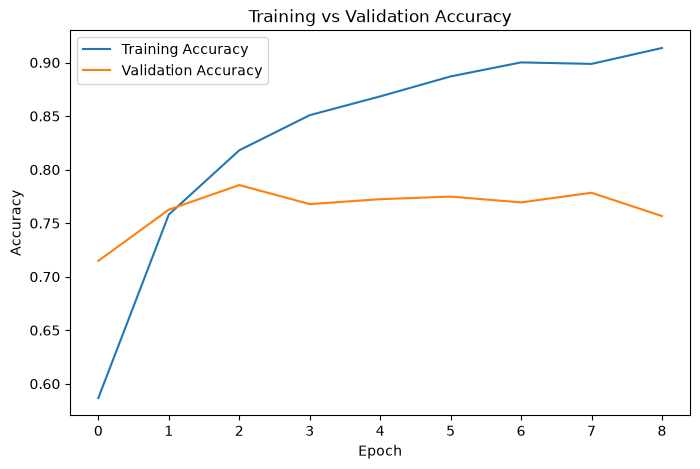

In [12]:
history_data = history.history

# Loss curve
plt.figure(figsize=(8, 5))
plt.plot(history_data["loss"], label="Training Loss")
plt.plot(history_data["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# Accuracy curve
plt.figure(figsize=(8, 5))
plt.plot(history_data["accuracy"], label="Training Accuracy")
plt.plot(history_data["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

## 12. Evaluate on the Test Set

The test set is kept separate from model fitting and validation. It provides the final evaluation on unseen reviews.

In [13]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.7630 - loss: 0.4991
Test Loss: 0.4991
Test Accuracy: 0.7630


## 13. Additional Classification Metrics

Accuracy alone can hide differences between the two classes. We therefore calculate precision, recall, F1-score, and a confusion matrix on the test set.

              precision    recall  f1-score   support

    Negative     0.7464    0.7966    0.7707     12500
    Positive     0.7819    0.7294    0.7547     12500

    accuracy                         0.7630     25000
   macro avg     0.7642    0.7630    0.7627     25000
weighted avg     0.7642    0.7630    0.7627     25000



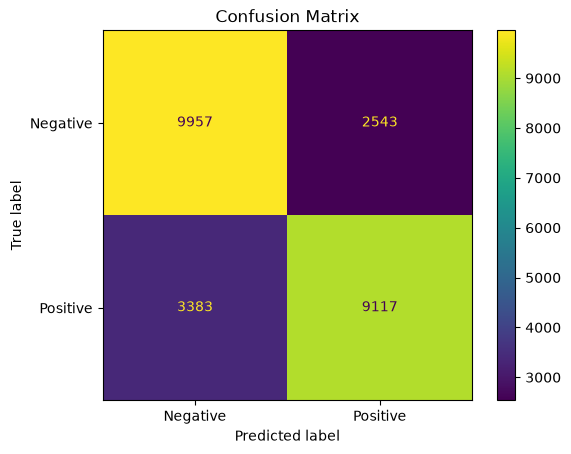

In [14]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

y_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Positive"],
    digits=4
))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

## 14. Save the Trained Model

The notebook lives under `notebooks/`, while trained models belong under the project's `models/` directory.

We save:

- `.keras` → modern Keras model format
- `.h5` → retained for compatibility with the current Streamlit workflow

The code detects the project root so the model is saved in the correct folder regardless of whether the notebook runs from the project root or the `notebooks/` directory.

In [15]:
from pathlib import Path

project_root = Path.cwd()

if not (project_root / "models").exists() and (project_root.parent / "models").exists():
    project_root = project_root.parent

model_dir = project_root / "models"
model_dir.mkdir(parents=True, exist_ok=True)

keras_path = model_dir / "simple_rnn_imdb.keras"
h5_path = model_dir / "simple_rnn_imdb.h5"

model.save(keras_path)
model.save(h5_path)

print("Keras model:", keras_path.resolve())
print("H5 model:   ", h5_path.resolve())

Keras model: E:\imdb-movie-review-sentiment-analysis-simple-rnn\models\simple_rnn_imdb.keras
H5 model:    E:\imdb-movie-review-sentiment-analysis-simple-rnn\models\simple_rnn_imdb.h5


## 15. Final Model Sanity Check

Before moving to the Streamlit application, verify that the saved model can be loaded and used for inference.

The test below loads the `.keras` model and makes one prediction on the first test review.

In [16]:
from tensorflow.keras.models import load_model

saved_model = load_model(keras_path, compile=False)

sample_prediction = saved_model.predict(
    X_test[0:1],
    verbose=0
)

print("Test review prediction score:", float(sample_prediction[0][0]))
print(
    "Predicted sentiment:",
    "Positive" if sample_prediction[0][0] >= 0.5 else "Negative"
)

Test review prediction score: 0.18169556558132172
Predicted sentiment: Negative


## Key Takeaways

- IMDB reviews are represented as integer token sequences.
- Padding converts variable-length reviews into fixed-length inputs.
- The Embedding layer converts token IDs into dense vectors.
- The Simple RNN processes the embedded sequence and learns sequential patterns.
- A sigmoid output is used for binary sentiment classification.
- Early Stopping helps avoid unnecessary training and restores the best validation weights.
- Test-set metrics provide the final evaluation on unseen reviews.
- The trained model is saved inside the project's `models/` directory.
- The saved model can then be reused by the prediction notebook and Streamlit application.

### Next Step

Use the saved model in `03_prediction.ipynb` for inference on new reviews, and then connect the same inference pipeline to the Streamlit application.